In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sleep_health_data = pd.read_csv("../data/cleaned/cleaned.csv", keep_default_na=False)


In [3]:
display(sleep_health_data.describe())


,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Systolic BP,Diastolic BP
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920,128.553476,84.649733
std,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679,7.748118,6.161611
min,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000,115.000000,75.000000
25%,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000,125.000000,80.000000
50%,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000,130.000000,85.000000
75%,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000,135.000000,90.000000
max,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000,142.000000,95.000000


In [4]:
display(sleep_health_data.info())
print()
print("Missing values checking:")
display(sleep_health_data.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   374 non-null    str    
 1   Age                      374 non-null    int64  
 2   Occupation               374 non-null    str    
 3   Sleep Duration           374 non-null    float64
 4   Quality of Sleep         374 non-null    int64  
 5   Physical Activity Level  374 non-null    int64  
 6   Stress Level             374 non-null    int64  
 7   BMI Category             374 non-null    str    
 8   Heart Rate               374 non-null    int64  
 9   Daily Steps              374 non-null    int64  
 10  Sleep Disorder           374 non-null    str    
 11  Systolic BP              374 non-null    int64  
 12  Diastolic BP             374 non-null    int64  
dtypes: float64(1), int64(8), str(4)
memory usage: 38.1 KB


None


Missing values checking:


Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Heart Rate                 0
Daily Steps                0
Sleep Disorder             0
Systolic BP                0
Diastolic BP               0
dtype: int64

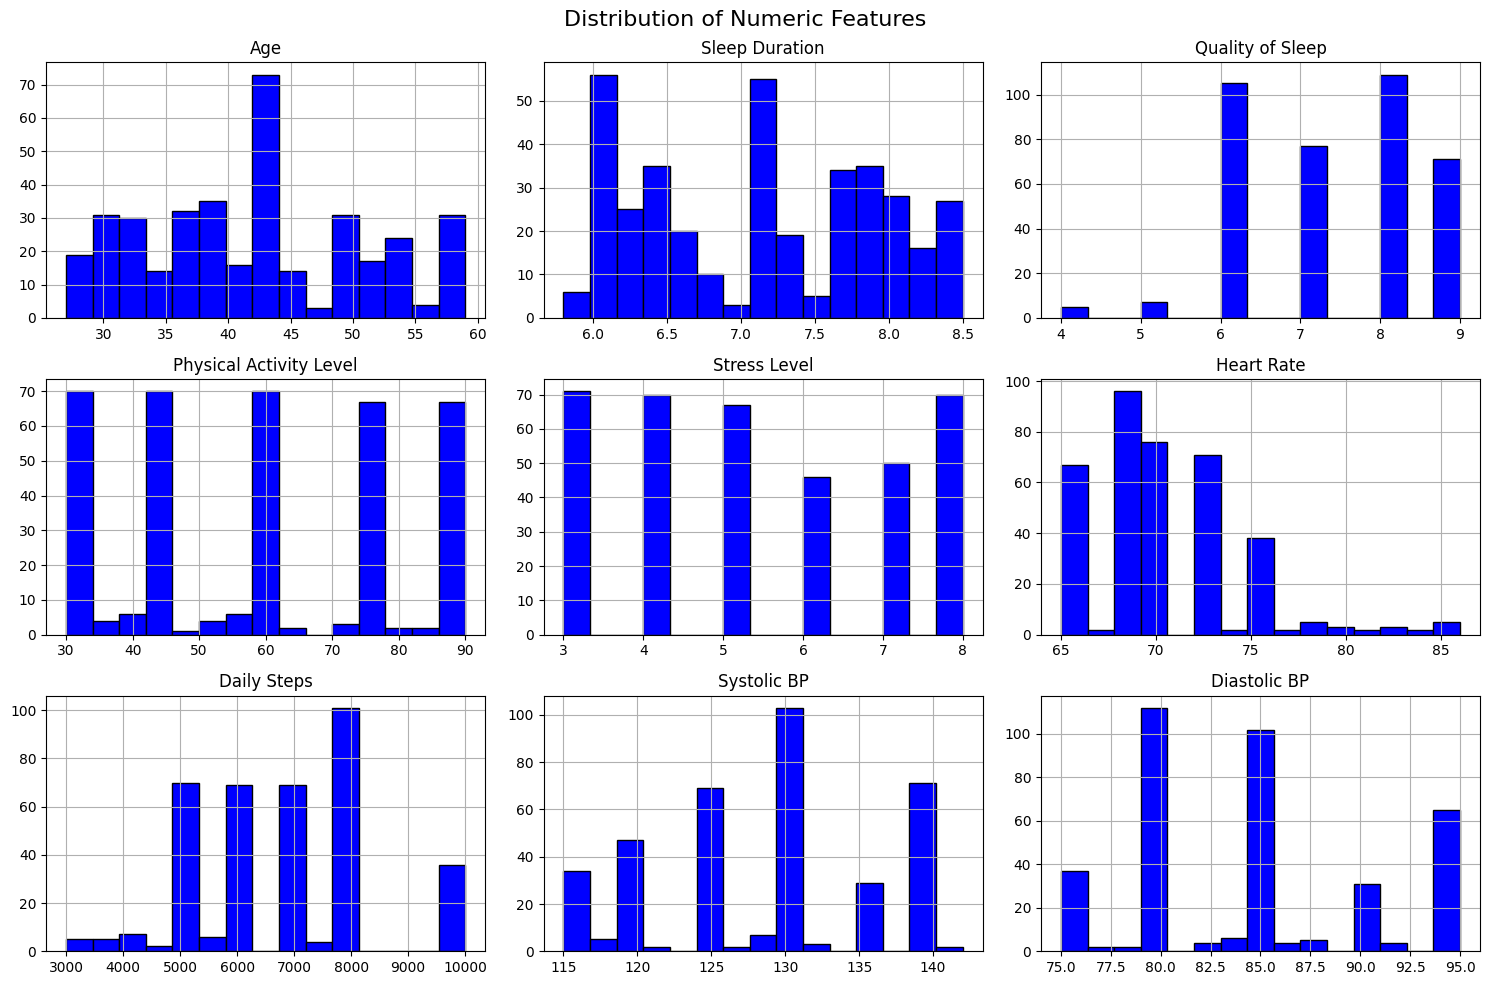

In [14]:
sleep_health_data.hist(bins=15, figsize=(15,10), color='blue', edgecolor='black')
plt.suptitle("Distribution of Numeric Features", fontsize=16)
plt.tight_layout()
plt.show()

These plots show how the numeric features are distributed. Most values look fairly normal, but the scales are very different (e.g., Daily Steps vs others), so scaling will be important.

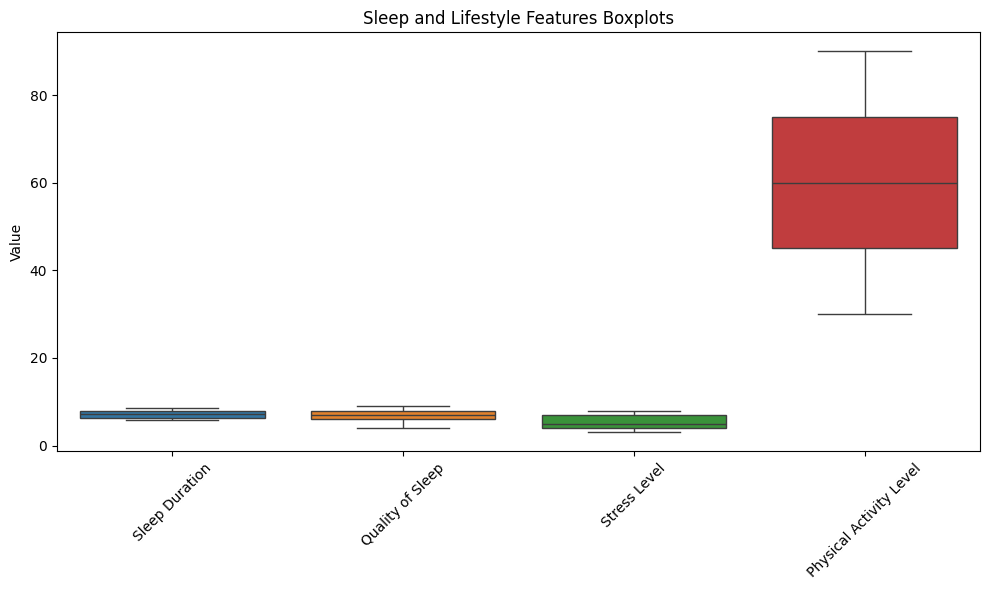

In [6]:
sleep_lifestyle_cols = [
    "Sleep Duration",
    "Quality of Sleep",
    "Stress Level",
    "Physical Activity Level"
]

plt.figure(figsize=(10, 6))
sns.boxplot(data=sleep_health_data[sleep_lifestyle_cols])
plt.title("Sleep and Lifestyle Features Boxplots")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Features like Daily Steps are on a much larger scale → scaling is necessary.

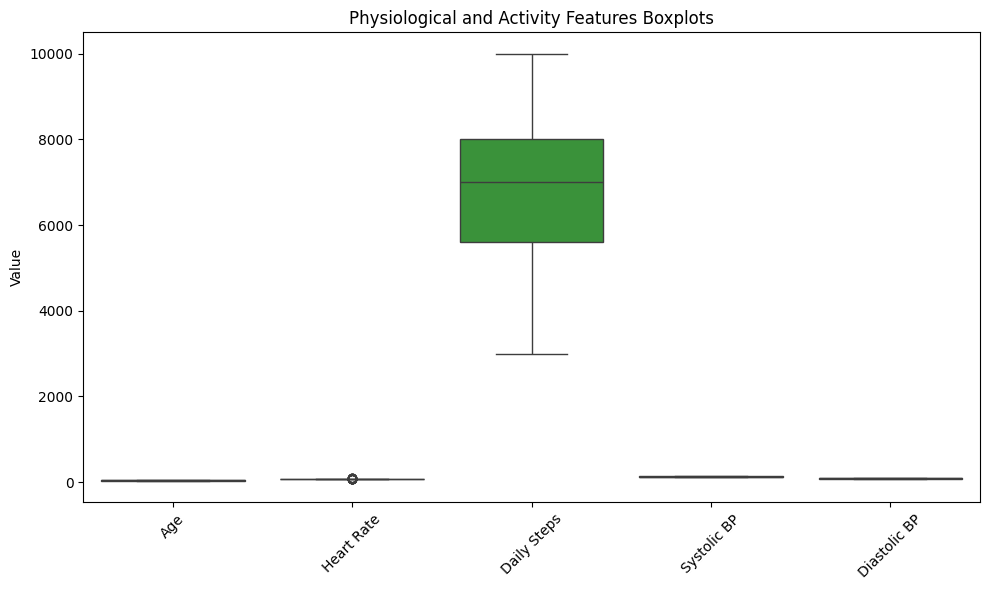

In [7]:
physiology_cols = [
    "Age",
    "Heart Rate",
    "Daily Steps",
    "Systolic BP",
    "Diastolic BP"
]

plt.figure(figsize=(10, 6))
sns.boxplot(data=sleep_health_data[physiology_cols])
plt.title("Physiological and Activity Features Boxplots")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

No extreme outliers. Features are well-behaved and suitable for standard scaling.

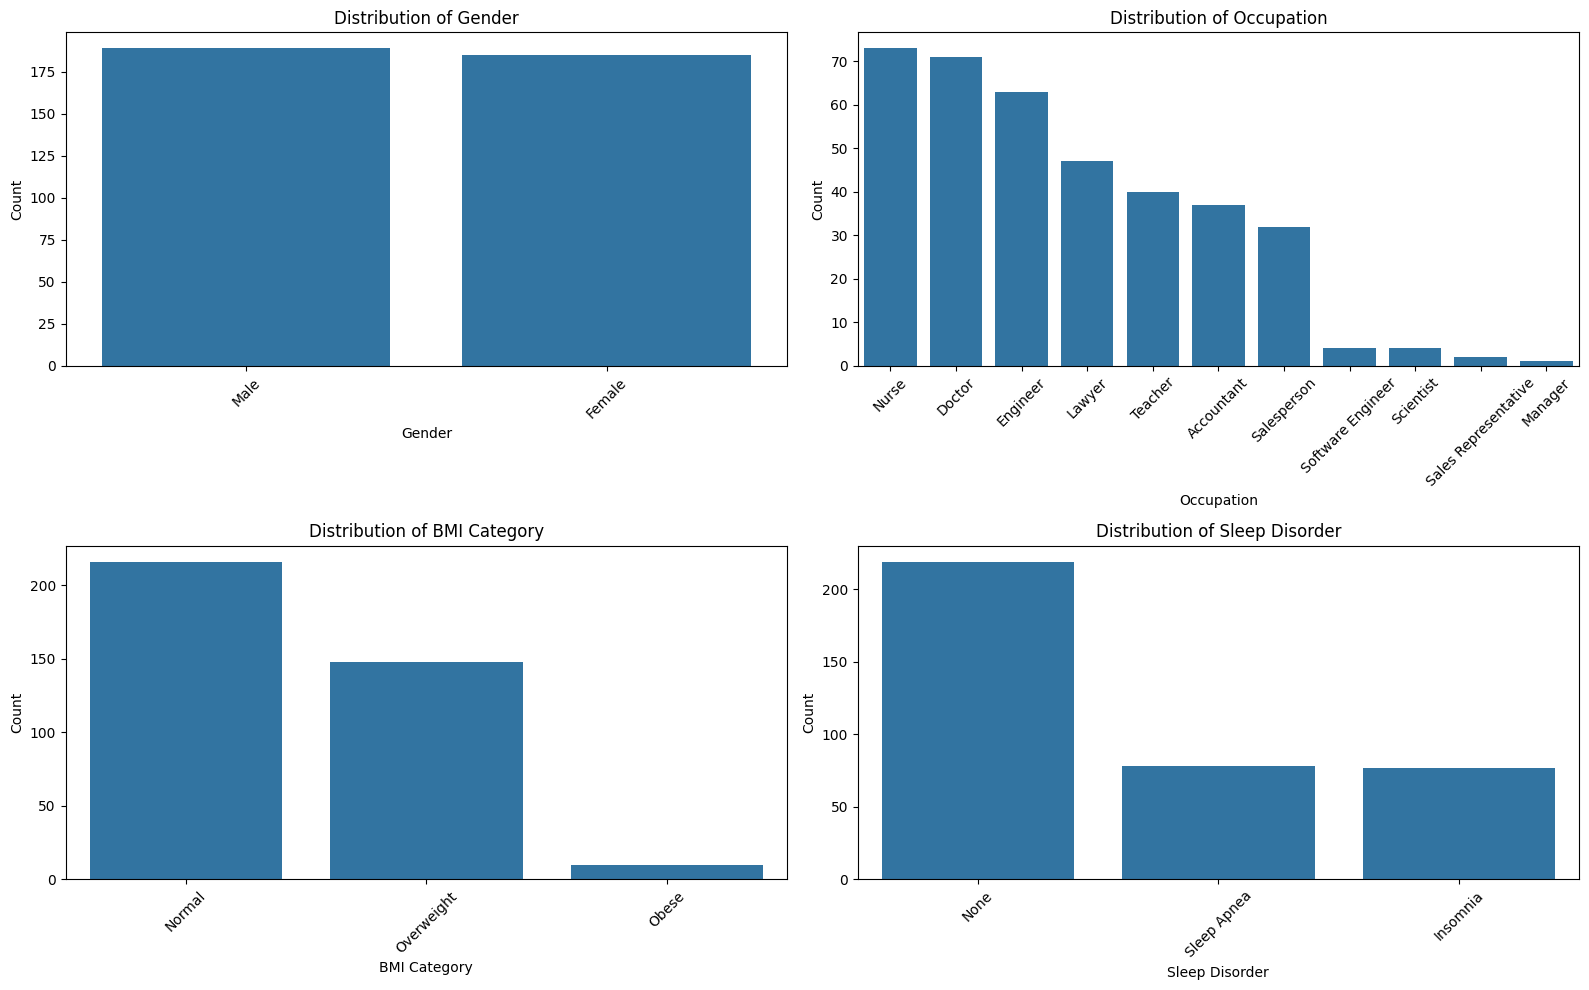

In [8]:
categorical_cols = [
    "Gender",
    "Occupation",
    "BMI Category",
    "Sleep Disorder"
]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    order = sleep_health_data[col].value_counts().index
    sns.countplot(data=sleep_health_data, x=col, order=order, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

The categorical plots show how values like gender, occupation, and BMI are distributed in the dataset. Most importantly, the target variable is imbalanced, with more “None” cases than actual sleep disorders. This suggests we need to be careful when evaluating model performance and use metrics beyond accuracy.

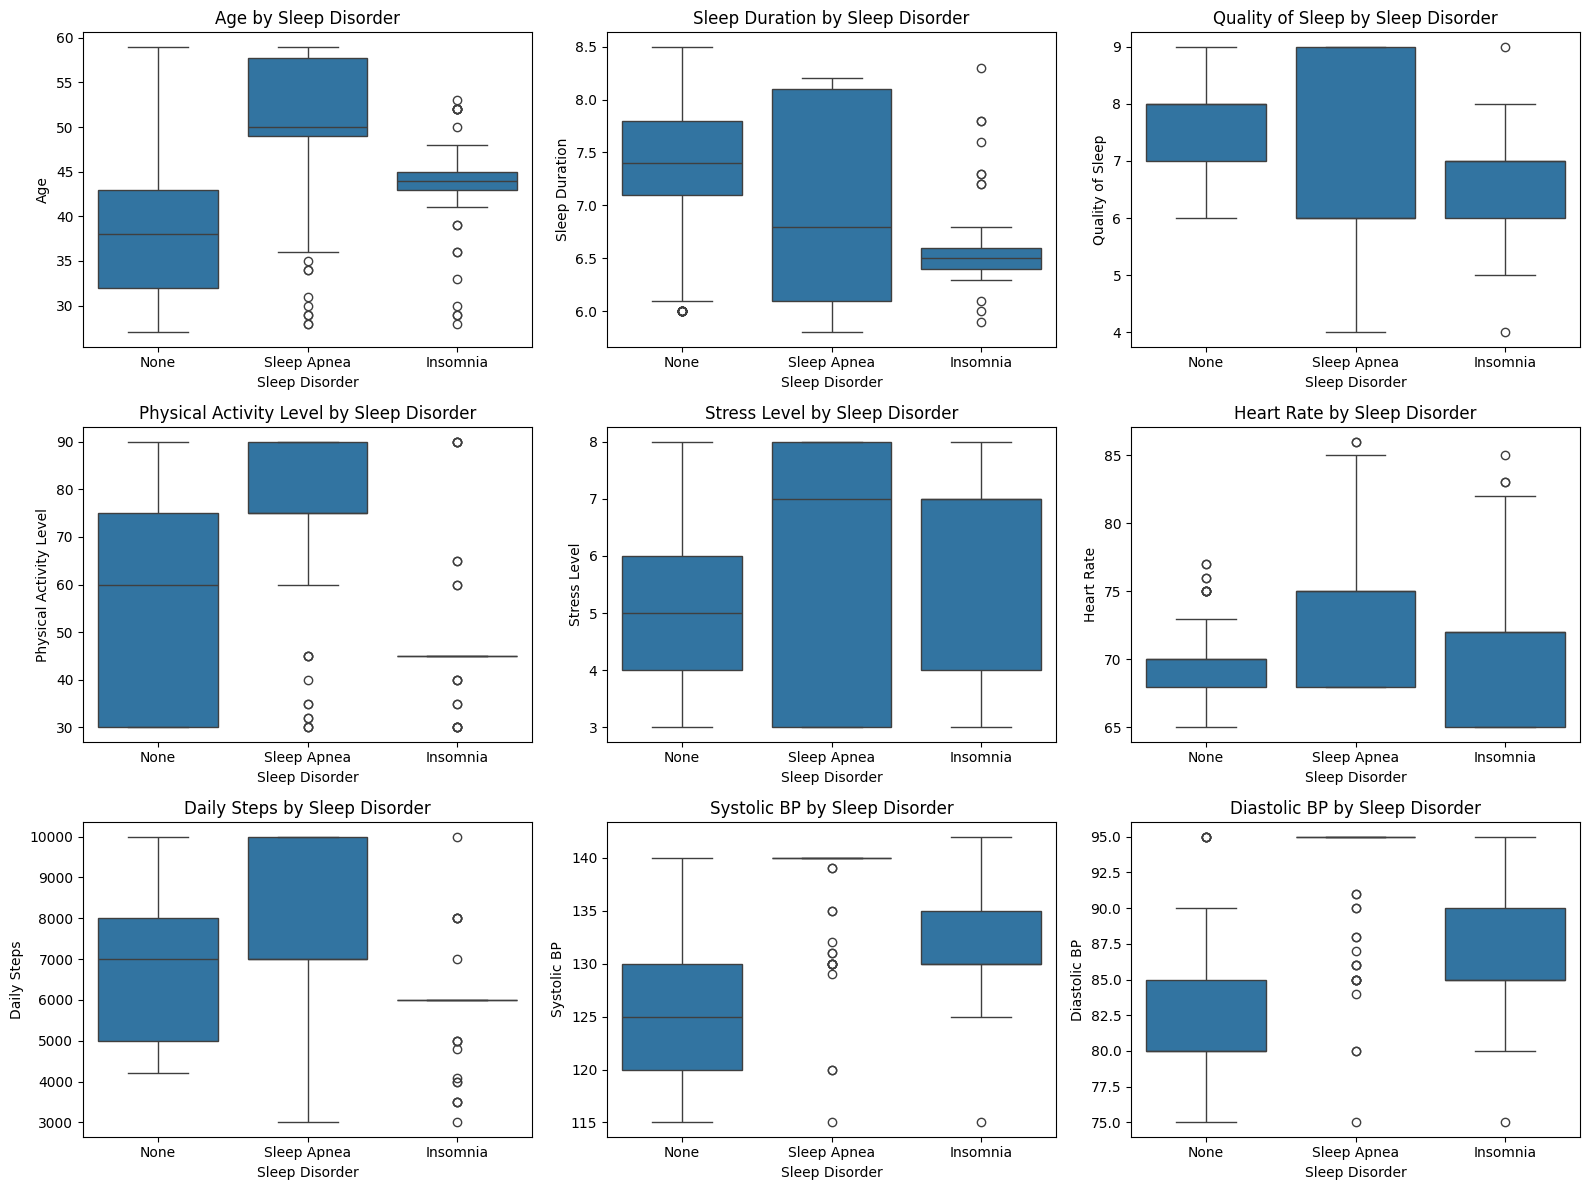

In [9]:
numeric_cols = [
    "Age",
    "Sleep Duration",
    "Quality of Sleep",
    "Physical Activity Level",
    "Stress Level",
    "Heart Rate",
    "Daily Steps",
    "Systolic BP",
    "Diastolic BP"
]

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=sleep_health_data, x="Sleep Disorder", y=col, ax=axes[i])
    axes[i].set_title(f"{col} by Sleep Disorder")
    axes[i].set_xlabel("Sleep Disorder")
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

These grouped boxplots compare each numeric feature across the three sleep disorder classes. They help identify which variables show noticeable differences in median, spread, and outliers by class. Features such as Sleep Duration and Quality of Sleep show clearer separation, while others may overlap more and contribute less strongly on their own.

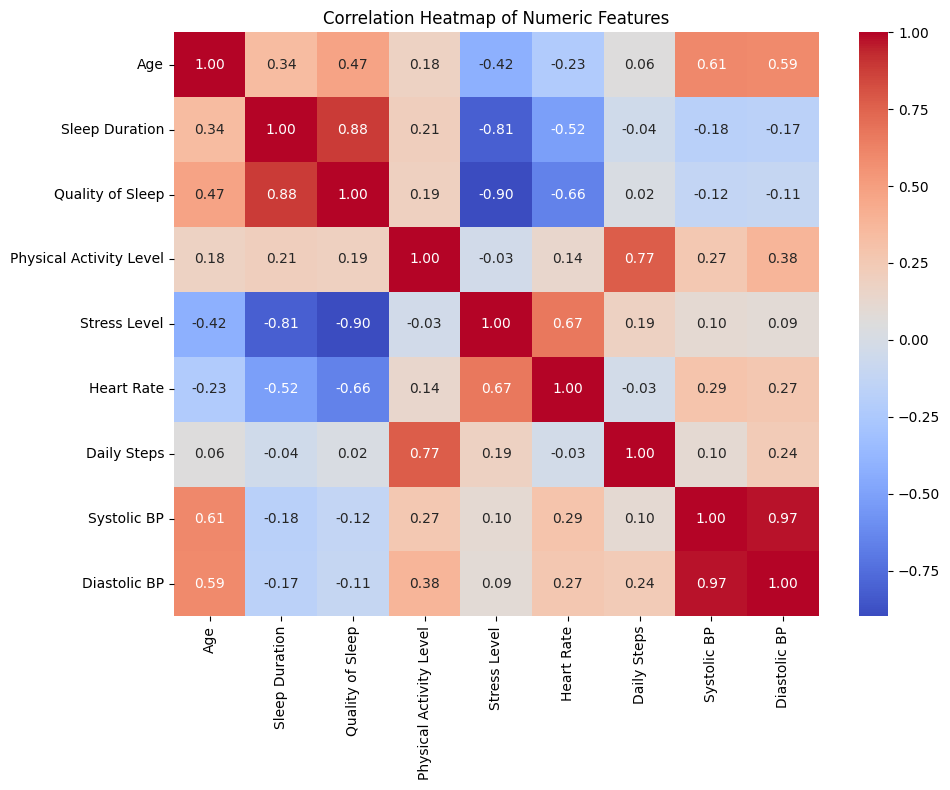

In [10]:
numeric_data = sleep_health_data.select_dtypes(include="number")
corr = numeric_data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

Some features are related, but no strong redundancy. All can still contribute to the model.